In [1]:
%run scripts/dowload_data.py


HIGGS DATASET PREPARATION

[1/4] Downloading dataset
------------------------------------------------------------
The compressed HIGGS dataset already exists. Skipping download.

[2/4] Loading original dataset
------------------------------------------------------------
Samples:  11,000,000
Features: 28
Columns:  29

Class distribution:
  Class 0: 47.01%
  Class 1: 52.99%

[3/4] Creating 100% experimental reference dataset
------------------------------------------------------------
Original size:   11,000,000
Target size:     1,000,000
Sampling method: Stratified sampling
Random seed:     42

100% reference dataset:
  Samples: 1,000,000

Class distribution:
  Class 0: 47.01%
  Class 1: 52.99%

[4/4] Generating datasets
------------------------------------------------------------

   10% |    100,000 samples | Class 0: 47.05% | Class 1: 52.95%
  Saved to: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\BLOQUE_BIGDATA\BIGDATA_2\ANALYTICS\ENTREGA\proyecto\data\higgs-10.csv

   20% |   

In [1]:
%run scripts/AL_performance.py 16 10 smart 5 AL_performance.csv


 STARTING SPARK ACTIVE LEARNING
Spark session initialized successfully on 'local[16]'

 LOAD AND PREPROCESS DATASET
load_and_preprocess_data():
	- Dataset loaded successfully from 'C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\BLOQUE_BIGDATA\BIGDATA_2\ANALYTICS\ENTREGA\proyecto\data\higgs-10.csv'
	- Data types converted:
		-ID and label to INT
		-features to FLOAT.
	- Feature columns assembled into 'features' vector column
	- Dataset split into training and test sets.
	- Features standardized using statistics computed from the training set.
	- Training set initialized with approximately 5.0% labeled instances.

EXPERIMENT SETUP
Dataset configuration:
  Train/Test split: [0.7, 0.3]
  Total dataset size: 100,000 instances
  Training set size: 70,342 instances
  Test set size: 29,658 instances

Initial training set state:
  Labeled (L):   3,508 instances (4.99%)
  Unlabeled (U): 66,834 instances (95.01%)
  Initial labeled fraction: 5.0% of training set size.

Active Learning configura

In [2]:
%run scripts/AL_performance.py 16 10 random 5 AL_performance.csv


 STARTING SPARK ACTIVE LEARNING
Spark session initialized successfully on 'local[16]'

 LOAD AND PREPROCESS DATASET
load_and_preprocess_data():
	- Dataset loaded successfully from 'C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\BLOQUE_BIGDATA\BIGDATA_2\ANALYTICS\ENTREGA\proyecto\data\higgs-10.csv'
	- Data types converted:
		-ID and label to INT
		-features to FLOAT.
	- Feature columns assembled into 'features' vector column
	- Dataset split into training and test sets.
	- Features standardized using statistics computed from the training set.
	- Training set initialized with approximately 5.0% labeled instances.

EXPERIMENT SETUP
Dataset configuration:
  Train/Test split: [0.7, 0.3]
  Total dataset size: 100,000 instances
  Training set size: 70,342 instances
  Test set size: 29,658 instances

Initial training set state:
  Labeled (L):   3,508 instances (4.99%)
  Unlabeled (U): 66,834 instances (95.01%)
  Initial labeled fraction: 5.0% of training set size.

Active Learning configura

method,labeled_percentage,Random Selection,Uncertainty + K-means
0,5.0,0.6256,0.6256
1,6.0,0.6304,0.6311
2,7.0,0.6303,0.6357
3,8.0,0.6303,0.6394
4,9.0,0.6291,0.6420
5,10.0,0.6280,0.6435


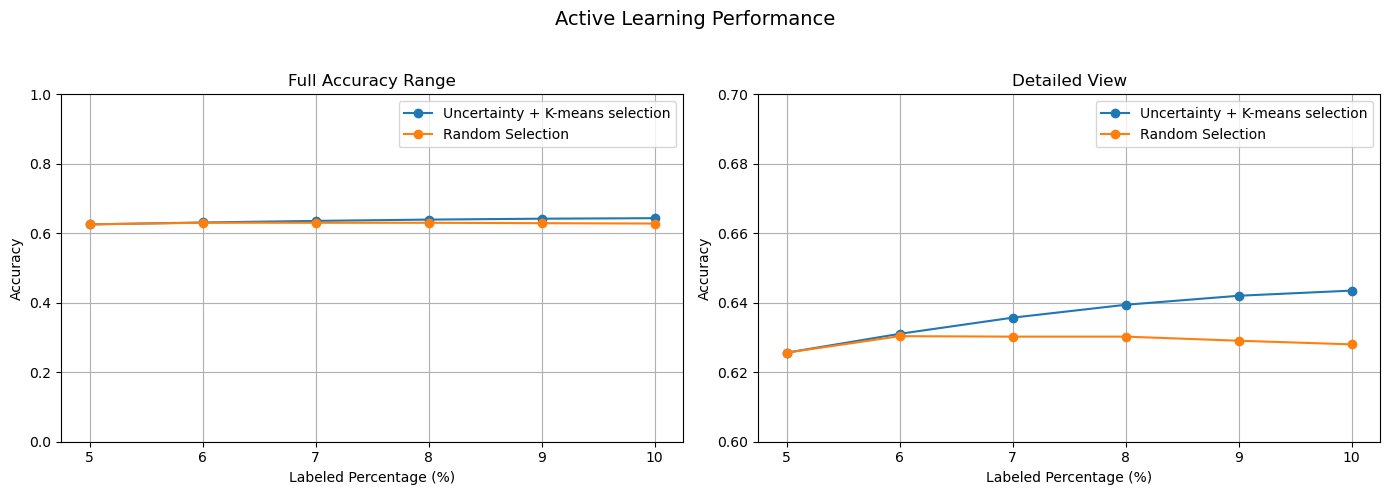

In [3]:
from scripts.plot_results import plot_performance_results

plot_performance_results("AL_performance.csv")

In [1]:
# ============================================================
# SPEED-UP
# ============================================================
#
# Para Speed-Up:
#
# - El tamaño del dataset se mantiene FIJO.
# - Cambiamos el número de cores.
#
# Aquí utilizamos el 10% del dataset.
#
# Experimentos:
#
#   (1 core, 100%)
#   (2 cores, 100%)
#   (4 cores, 100%)
#   (8 cores, 100%)
#   (12 cores, 100%)
#
# Cada experimento se repite 5 veces.
# ============================================================
print("===== SPEED-UP =====")
num_repetitions = 1
num_cores = [1, 2, 4, 8, 10]
percentage_set = 40
for cores in num_cores:

    for i in range(num_repetitions):
        print()
        print("-"*60)
        print(
            f"Cores={cores} | "
            f"Repetition {i + 1}/{num_repetitions} | "
            f"Dataset={percentage_set}%"
        )

        %run scripts/AL_scalability.py $cores $percentage_set smart speed_up_bisectic.csv


print("Speed-Up experiment completed.\n")

===== SPEED-UP =====

------------------------------------------------------------
Cores=1 | Repetition 1/1 | Dataset=40%

 STARTING SPARK ACTIVE LEARNING
Spark session initialized successfully on 'local[1]'

 LOAD AND PREPROCESS DATASET
load_and_preprocess_data():
	- Dataset loaded successfully from 'C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\BLOQUE_BIGDATA\BIGDATA_2\ANALYTICS\ENTREGA\proyecto\data\higgs-40.csv'
	- Data types converted:
		-ID and label to INT
		-features to FLOAT.
	- Feature columns assembled into 'features' vector column
	- Dataset split into training and test sets.
	- Features standardized using statistics computed from the training set.
	- Training set initialized with approximately 5.0% labeled instances.

EXPERIMENT SETUP
Dataset configuration:
  Train/Test split: [0.7, 0.3]
  Total dataset size: 400,000 instances
  Training set size: 280,067 instances
  Test set size: 119,933 instances

Initial training set state:
  Labeled (L):   14,070 instances (5.02%)


In [2]:
# ============================================================
# SIZE-UP
# ============================================================
#
# Para Size-Up:
#
# - El número de cores se mantiene FIJO.
# - Aumentamos el tamaño del dataset.
#
# Utilizamos 4 cores para todos los experimentos.
#
# Experimentos:
#
#   (4 cores, 10%)
#   (4 cores, 20%)
#   (4 cores, 40%)
#   (4 cores, 80%)
#   (4 cores, 100%)
#
# Cada experimento se repite 10 veces.
# ============================================================
print("===== SIZE-UP =====")
num_repetitions = 1
cores = 4
percentage_set = [10, 20, 40, 80, 100]
for percentage in percentage_set:

    for i in range(num_repetitions):
        print()
        print("-"*60)
        print(
            f"Dataset={percentage}% | " 
            f"Repetition {i + 1}/{num_repetitions} | "
            f"Cores={cores}"
        )

        %run scripts/AL_scalability.py $cores $percentage smart size_up_bisectic.csv


print("Size-Up experiment completed.\n")

===== SIZE-UP =====

------------------------------------------------------------
Dataset=10% | Repetition 1/1 | Cores=4

 STARTING SPARK ACTIVE LEARNING
Spark session initialized successfully on 'local[4]'

 LOAD AND PREPROCESS DATASET
load_and_preprocess_data():
	- Dataset loaded successfully from 'C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\BLOQUE_BIGDATA\BIGDATA_2\ANALYTICS\ENTREGA\proyecto\data\higgs-10.csv'
	- Data types converted:
		-ID and label to INT
		-features to FLOAT.
	- Feature columns assembled into 'features' vector column
	- Dataset split into training and test sets.
	- Features standardized using statistics computed from the training set.
	- Training set initialized with approximately 5.0% labeled instances.

EXPERIMENT SETUP
Dataset configuration:
  Train/Test split: [0.7, 0.3]
  Total dataset size: 100,000 instances
  Training set size: 70,228 instances
  Test set size: 29,772 instances

Initial training set state:
  Labeled (L):   3,584 instances (5.10%)
  Un

In [3]:
# ============================================================
# SCALE-UP
# ============================================================
#
# Para Scale-Up aumentamos proporcionalmente:
#
#       número de cores
#
# y:
#
#       tamaño del dataset.
#
# Utilizamos las parejas:
#
#       1 core  -> 10%
#       2 cores -> 20%
#       4 cores -> 40%
#       8 cores -> 80%
#       12 cores -> 100%
#
# IMPORTANTE:
# En el script original de las diapositivas se utilizaba:
#
#       [1, 2, 4, 8, 10]
#
# porque los tamaños eran:
#
#       [10, 20, 40, 80, 100]
#
# Si queremos que la última ejecución utilice 12 cores,
# ya no existe una relación estrictamente proporcional.
#
# Por tanto, aquí utilizaremos 10 cores para el último punto.
# ============================================================

scaleup_cores = [1, 2, 4, 8, 10]
scaleup_sizes = [10, 20, 40, 80, 100]
num_repetitions = 1


print("===== SCALE-UP =====")

for cores, percentage in zip(
    scaleup_cores,
    scaleup_sizes
):
    for i in range(num_repetitions):
        print()
        print("-"*60)
        print(
            f"Dataset={percentage}% | " 
            f"Cores={cores} | "
            f"Repetition {i + 1}/{num_repetitions}"
        )

        %run scripts/AL_scalability.py $cores $percentage smart scale_up_bisectic.csv

print("Size-Up experiment completed.\n")        

===== SCALE-UP =====

------------------------------------------------------------
Dataset=10% | Cores=1 | Repetition 1/1

 STARTING SPARK ACTIVE LEARNING
Spark session initialized successfully on 'local[1]'

 LOAD AND PREPROCESS DATASET
load_and_preprocess_data():
	- Dataset loaded successfully from 'C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\BLOQUE_BIGDATA\BIGDATA_2\ANALYTICS\ENTREGA\proyecto\data\higgs-10.csv'
	- Data types converted:
		-ID and label to INT
		-features to FLOAT.
	- Feature columns assembled into 'features' vector column
	- Dataset split into training and test sets.
	- Features standardized using statistics computed from the training set.
	- Training set initialized with approximately 5.0% labeled instances.

EXPERIMENT SETUP
Dataset configuration:
  Train/Test split: [0.7, 0.3]
  Total dataset size: 100,000 instances
  Training set size: 69,941 instances
  Test set size: 30,059 instances

Initial training set state:
  Labeled (L):   3,571 instances (5.11%)
  U

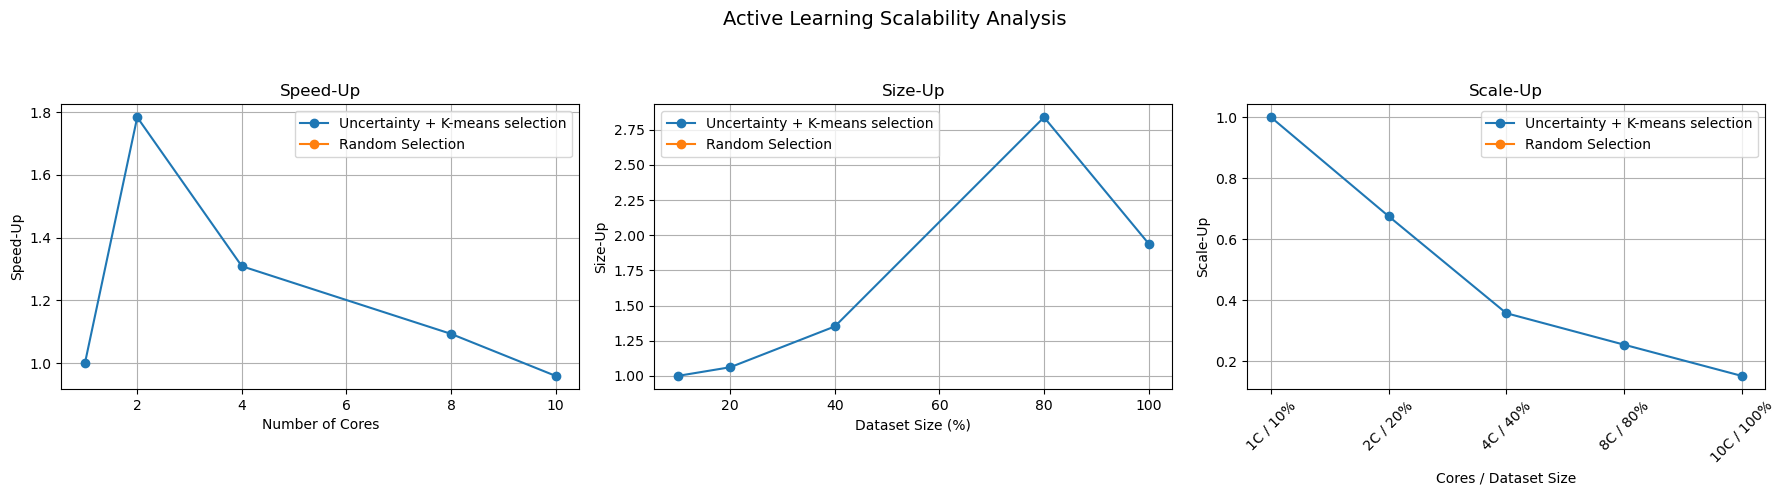

In [1]:
from scripts.plot_results import plot_scalability

plot_scalability("speed_up_bisectic.csv", "size_up_bisectic.csv", "scale_up_bisectic.csv")